Created 10/11/2022

want to analyze how things change throughout the learning process - we have samples from epoch 100,200,300,400 and 500 (end of training). this should be enough data points. 

should we focus on sir3 - because we can easily calculate out of cluster variance for sir3 - lets just use this one example. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions


In [2]:
def CalcOCV(df_recall, stim_diff = 360, var = 'var', df = [], uniform = False):
    stim_diff_half = stim_diff/2
    decodeout = df_recall['#OutDecode']
    target = df_recall['#OutTarget']
    trials = len(df_recall)
    
    err = []
    ocv = []
    mod_lab = []
    trialname = []
    
    for i in range(trials):
        t = df_recall.iloc[i]['$TrialName']
        recall = t.split('Recall')[1].split('_')[0]
        if recall == '1':
            mnt1 = float(t.split('_')[1])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3= float(t.split('mnt3_')[1].split('_')[0])
        if recall=='2':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('_')[1])
            mnt3 = float(t.split('mnt3_')[1].split('_')[0]) 
        if recall=='3':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3 = float(t.split('_')[1])
        
        if uniform:
            ind_r = df_recall.iloc[i]['ind']
            tr = df[df['ind'] == (ind_r-1)]
            t_un = tr['$TrialName'][0]
            #print(t_un)
            mnt1 = float(t_un.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t_un.split('mnt2_')[1].split('_')[0])
            mnt3= float(t_un.split('mnt3_')[1].split('_')[0])
            #print(mnt1)
            #print(mnt2)
            #print(mnt3)

        if mnt1 != -1 and mnt2 != -1 and mnt3 != -1:
            decodeout = df_recall.iloc[i]['#OutDecode']
            target = df_recall.iloc[i]['#OutTarget']
            diff = decodeout-target
            diff_mod = np.mod(diff+stim_diff_half, stim_diff)-stim_diff_half
            err.append(diff_mod)
            mod_lab.append(df_recall.iloc[i]['mod_lab'])
            trialname.append(t)
            
            if recall == '1':
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3], high = 360))
                elif var == 'diff':
                    ocv.append(np.mod(mnt2-mnt3+stim_diff_half, stim_diff)-stim_diff_half)
            if recall == '2':
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                elif var == 'diff':
                    ocv.append(np.mod(mnt1-mnt3+stim_diff_half, stim_diff)-stim_diff_half)
            if recall == '3':
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                elif var == 'diff':
                    ocv.append(np.mod(mnt1-mnt2+stim_diff_half, stim_diff)-stim_diff_half)
    #print(ocv)
    #import pdb; pdb.set_trace
    return ocv, err, mod_lab, trialname

def CalcOCVsir4(df_recall, stim_diff = 360, var = 'var'):
    stim_diff_half = stim_diff/2
    decodeout = df_recall['#OutDecode']
    target = df_recall['#OutTarget']
    trials = len(df_recall)
    
    err = []
    ocv = []
    mod_lab = []
    trialname = []
    
    for i in range(trials):
        t = df_recall.iloc[i]['$TrialName']
        recall = t.split('Recall')[1].split('_')[0]
        
        append_rest = False
        
        if recall == '1':
            mnt1 = float(t.split('_')[1])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3= float(t.split('mnt3_')[1].split('_')[0])
            mnt4 = float(t.split('mnt4_')[1].split('_')[0])
            
            if mnt2 != -1 and mnt3 !=-1 and mnt4 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3,mnt4], high = 360))
                append_rest = True
            elif mnt2 != -1 and mnt3 != -1 and mnt4 == -1: # 3/4 stimuli, no mnt4
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3], high = 360))
                append_rest = True
            elif mnt2 != -1 and mnt3 == -1 and mnt4 != -1:# 3/4 stimuli, no mnt3
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt4], high = 360))
                append_rest = True
            elif mnt2 == -1 and mnt3 != -1 and mnt4 != -1: # 3/4 stimuli, no mnt2
                if var == 'var':
                    ocv.append(np.var([mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt3,mnt4], high = 360))
                append_rest = True 
            
        if recall=='2':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('_')[1])
            mnt3 = float(t.split('mnt3_')[1].split('_')[0]) 
            mnt4 = float(t.split('mnt4_')[1].split('_')[0])
            
            
            if mnt1 != -1 and mnt3 !=-1 and mnt4 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3,mnt4], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt3 != -1 and mnt4 == -1: # 3/4 stimuli, no mnt4
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt3 == -1 and mnt4 != -1:# 3/4 stimuli, no mnt3
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt4], high = 360))
                append_rest = True
            elif mnt1 == -1 and mnt3 != -1 and mnt4 != -1: # 3/4 stimuli, no mnt1
                if var == 'var':
                    ocv.append(np.var([mnt3,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt3,mnt4], high = 360))
                append_rest = True 
            
        if recall=='3':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3 = float(t.split('_')[1])
            mnt4 = float(t.split('mnt4_')[1].split('_')[0])
            
            if mnt1 != -1 and mnt2 !=-1 and mnt4 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2,mnt4], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 != -1 and mnt4 == -1: # 3/4 stimuli, no mnt4
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 == -1 and mnt4 != -1:# 3/4 stimuli, no mnt2
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt4], high = 360))
                append_rest = True
            elif mnt1 == -1 and mnt2 != -1 and mnt4 != -1: # 3/4 stimuli, no mnt1
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt4]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt4], high = 360))
                append_rest = True 
        if recall=='4':
            mnt1 = float(t.split('mnt1_')[1].split('_')[0])
            mnt2 = float(t.split('mnt2_')[1].split('_')[0])
            mnt3 = float(t.split('mnt3_')[1].split('_')[0]) 
            mnt4 = float(t.split('_')[1])
            
            if mnt1 != -1 and mnt2 !=-1 and mnt3 != -1: #all stimuli
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2,mnt3], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 != -1 and mnt3 == -1: # 3/4 stimuli, no mnt3
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt2]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt2], high = 360))
                append_rest = True
            elif mnt1 != -1 and mnt2 == -1 and mnt3 != -1:# 3/4 stimuli, no mnt2
                if var == 'var':
                    ocv.append(np.var([mnt1,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt1,mnt3], high = 360))
                append_rest = True
            elif mnt1 == -1 and mnt2 != -1 and mnt3 != -1: # 3/4 stimuli, no mnt1
                if var == 'var':
                    ocv.append(np.var([mnt2,mnt3]))
                elif var == 'circvar':
                    ocv.append(scipy.stats.circvar([mnt2,mnt3], high = 360))
                append_rest = True 
            #should all 4 be filled or 3/4 or 4/4 is okay - 3/4 or 4/4 is okay. 
        if append_rest == True: 
            decodeout = df_recall.iloc[i]['#OutDecode']
            target = df_recall.iloc[i]['#OutTarget']
            diff = decodeout-target
            diff_mod = np.mod(diff+stim_diff_half, stim_diff)-stim_diff_half
            err.append(diff_mod)
            mod_lab.append(df_recall.iloc[i]['mod_lab'])
            trialname.append(t)
        append_rest = False

    return ocv, err, mod_lab,trialname

def equalObs(x, nbin):
    nlen = len(x)
    return np.interp(np.linspace(0, nlen, nbin + 1),
                     np.arange(nlen),
                     np.sort(x))


def binnedaverage(df,xcol,ycol,binwidth =0.5, mintrial = 0, bins_equal_size = False, nbins = 20, own_bins = []):
    #x is the values that you want to bin over, y is the responses that will be averaged according to, df is the dataframe
    df = df.sort_values(xcol)
    xmin = np.min(df[xcol])
    xmax = np.max(df[xcol])
    #import pdb; pdb.set_trace()
    if len(own_bins) == 0 :
        bins = np.arange(xmin,xmax,binwidth)
        if bins_equal_size:
            bins = equalObs(df[xcol],nbins)
    else:
        bins = own_bins
    #np.digitize(df[x],bins = bins)
    OCVbin  = []
    AbsErrbin = []
    AbsErrvar = []
    lowlim = bins[0]
    for uplim in bins[1:]:
        df_temp = pd.DataFrame() 
        for row in df.iterrows():
            if row[1][xcol]<uplim and row[1][xcol]>=lowlim:
                df_temp = df_temp.append(row[1])
        lowlim = uplim
        
        if len(df_temp) != 0:
            #import pdb; pdb.set_trace()
            TErr = np.mean(df_temp.groupby('mod_lab').apply(np.mean,axis = 0)['AbsoluteError'])
            TOCV= np.mean(df_temp.groupby('mod_lab').apply(np.mean,axis = 0)['logOCV'])
            TErrvar = np.mean(df_temp.groupby('mod_lab').apply(np.var,axis = 0)['AbsoluteError'])
            TOCVvar= np.mean(df_temp.groupby('mod_lab').apply(np.var,axis = 0)['logOCV'])
            if len(df_temp) < mintrial:
                print(df_temp)
                print('excluded')
            else:
                OCVbin.append(TOCV)
                AbsErrbin.append(TErr)
                AbsErrvar.append(TErrvar)
            
        #TErr,TOCV = df_temp.apply(np.mean,axis = 0)
        #TErrvar,OCVvar = df_temp.apply(np.var,axis = 0)
    return OCVbin,AbsErrbin, AbsErrvar
            
#df.apply(checkrow,axis = 1, args = (uplim,xcol, df_temp,df))

    
def checkrow(x,uplim,xcol,df_temp,df):
    if x[xcol]<uplim:
        df_temp = df_temp.append(x)

def plot_title(base):
    #model_name = base.split('workingmemory')[1].split('/')[1] 
    model_name = base.split('/')[1]
    if 'contexp' in base:
        rewardtype = 'Continuous Exponential'
    elif 'RewThresh' in base:
        rewardtype = 'Binary'
    else:
        rewardtype = 'Continuous Linear'
        
    if 'decodedrew' in base:
        rewardfun = 'Decoded'
    else: 
        rewardfun = 'Unit Difference'
        
    if 'NoStimLoc' in base:
        stimloc = ', No Stim Loc'
    else: 
        stimloc = ", Stim Loc Used"
   
    if 'NoIgnore' in base:
        ignore = ', No Ignore Trials'
    else:
        ignore = ''

    if "StimRange0to45" in base:
        stim_dist = ', StimDist Max 45'
    else:
        stim_dist = ""


    title = 'OCV ,' + model_name + ', Reward Function: ' + rewardtype +', ' +rewardfun +stimloc + ignore +stim_dist#+' '+additional_title
    return title

def getfiles(base):
    files = os.listdir(base)
    files = [f for f in files if 'Base' in f]
    full_files = [base+f for f in files if 'EpcLog' not in f]
    return full_files
#model = 0 
def model_labels(trial):
    new_model = []
    for tr in range(len(trial)):
        if tr == 0:
            pass
        else:
            if trial[tr]<trial[tr-1]:
                new_model.append(tr)
    new_model.append(len(trial))
    model = 0
    for i in range(len(new_model)):
        if i==0:
            model_tr = new_model[i]
            model_labels = np.repeat(model,model_tr)
        else:
            model_tr = new_model[i] - new_model[i-1]
            model_labels = np.append(model_labels,np.repeat(model,model_tr))
        model +=1
    
    return model_labels

    


def plot_ocv(base, var = 'var'):
    full_files = getfiles(base)
    p = Precision()
    err = p.mult_models(full_files)
    #plt.hist(err, bins = 50)
    #plt.title('Error Distribution for All Recall Trials')
    #plt.xlabel('Error')
    #plt.ylabel('Frequency')
    #plt.show()
    #p.dat.head()
    #import pdb; pdb.set_trace()
    df_recall = p.dat.loc['True']
    mod_labs = model_labels(np.array(df_recall['|Trial']))
    df_recall['mod_lab'] = mod_labs
    plt.figure()
    OCV,err, mod_lab = CalcOCV(df_recall, var = 'var')
    plt.scatter(OCV,err)
    title = plot_title(base)
    plt.title(title)
    plt.xlabel('Out of cluster Variance')
    
    logOCV = np.log(OCV)
    #n,bins,patches = plt.hist(logOCV, bins = 10)
    Odf = pd.DataFrame({'logOCV': logOCV, 'AbsoluteError':abs(np.array(err)), 'mod_lab':mod_lab})
    Odf = Odf.sort_values('logOCV')
    OCVbin,AbsErrbin, AbsErrvar = binnedaverage(Odf,'logOCV','AbsoluteError')
    
    
    plt.figure()
    #plt.scatter(OCVbin,AbsErrbin)
    stderror = np.sqrt(AbsErrvar)/np.sqrt(len(full_files))
    plt.errorbar(OCVbin, AbsErrbin, yerr=stderror, fmt="o")
    plt.xlabel('log(OCV)')
    plt.ylabel('Absolute Error')
    title = plot_title(base)
    plt.title('OCV Related to Performance \n'+title)
    plt.show()
    
def plot_ocv_two(base1,base2, var = 'var', mintrial = 0, extra_exp = '',chunkdf_recall= [],nochunkdf_recall= [], uniform = False, df_chunk  = [], df_nochunk = [], bins_equal_size = False, nbins = 20, own_bins = []):
    if "chunk" in base1: 
        chunk_file = base1
        file = base2
    elif "chunk" in base2:
        chunk_file = base2
        file = base1
    
    if len(chunkdf_recall) == 0:
        full_files = getfiles(chunk_file)
        if extra_exp != '':
            full_files = [f for f in full_files if extra_exp in f]
        #import pdb; pdb.set_trace()
        p = Precision()
        #if len(bad)>0

        err = p.mult_models(full_files)
        df = p.dat
        df['ind'] = range(len(df))
        df_recall = df.loc['True']
        #df_recall = p.dat.loc['True']
    else:
        df_recall = chunkdf_recall
    mod_labs = model_labels(np.array(df_recall['|Trial']))
    df_recall['mod_lab'] = mod_labs
    #return df_recall
    if len(df_chunk) == 0:
        df_chunk= df
    
    if 'sir3' in base1:
        if uniform:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var, uniform = True, df = df_chunk)
        else:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var)
            
    elif 'sir4' in base1: 
        OCV,err, mod_lab,trialname = CalcOCVsir4(df_recall, var = var)
        
    logOCV = np.log(np.abs(OCV))
    #logOCV = np.abs(OCV)
    #print('using OCV not logOCV')
    #logOCV = OCV
    #n,bins,patches = plt.hist(logOCV, bins = 10)
    

    
    Odf = pd.DataFrame({'logOCV': logOCV, 'AbsoluteError':abs(np.array(err)), 'mod_lab':mod_lab,'TrialName': trialname})
    Odf = Odf.sort_values('logOCV')
    
    #import pdb; pdb.set_trace()
    plt.figure()
    plt.scatter(Odf['logOCV'],Odf['AbsoluteError'])
    plt.title('Chunk Model')
    #print(Odf)
    chunk_OCVbin,chunk_AbsErrbin, chunk_AbsErrvar = binnedaverage(Odf,'logOCV','AbsoluteError', mintrial = mintrial,bins_equal_size = bins_equal_size, nbins = nbins,own_bins = own_bins)
    
    chunkOCV = OCV
    chunkOdf = Odf
    chunkdf_recall = df_recall
    
    
    if len(nochunkdf_recall)== 0:
        full_files = getfiles(file)
        if extra_exp != '':
            full_files = [f for f in full_files if extra_exp in f]
        p = Precision()
        err = p.mult_models(full_files)
        #df_recall = p.dat.loc['True']
        df = p.dat
        df['ind'] = range(len(df))
        df_recall = df.loc['True']
    else:
        df_recall = nochunkdf_recall
    
    if len(df_nochunk) == 0:
        df_nochunk= df
    mod_labs = model_labels(np.array(df_recall['|Trial']))
    df_recall['mod_lab'] = mod_labs

    if 'sir3' in base1:
        if uniform:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var, uniform = True, df = df_nochunk)
        else:
            OCV,err, mod_lab,trialname = CalcOCV(df_recall, var = var)
    elif 'sir4' in base1:
        OCV,err, mod_lab,trialname = CalcOCVsir4(df_recall, var = var)
    logOCV = np.log(np.abs(OCV))
    #logOCV = np.abs(OCV)
    #print('using OCV not logOCV')
    #logOCV = OCV
    #n,bins,patches = plt.hist(logOCV, bins = 10)

    Odf = pd.DataFrame({'logOCV': logOCV, 'AbsoluteError':abs(np.array(err)), 'mod_lab':mod_lab, 'TrialName': trialname})
    Odf = Odf.sort_values('logOCV')
    
    #plt.figure()
    plt.scatter(Odf['logOCV'],Odf['AbsoluteError'])
    plt.title('Chunk Model')
    nochunk_OCVbin,nochunk_AbsErrbin, nochunk_AbsErrvar = binnedaverage(Odf,'logOCV','AbsoluteError', mintrial = mintrial,bins_equal_size = bins_equal_size, nbins = nbins,own_bins = own_bins)
    
    nochunkOCV = OCV
    nochunkOdf = Odf
    nochunkdf_recall = df_recall
    
    plt.figure()
    #plt.scatter(OCVbin,AbsErrbin)
    if len(chunkdf_recall) ==0:
        num_models = len(full_files)
    else: 
        num_models = 160
    stderror = np.sqrt(chunk_AbsErrvar)/np.sqrt(num_models)
    plt.errorbar(chunk_OCVbin, chunk_AbsErrbin, yerr=stderror, fmt="o")
    
    stderror = np.sqrt(nochunk_AbsErrvar)/np.sqrt(num_models)
    plt.errorbar(nochunk_OCVbin, nochunk_AbsErrbin, yerr=stderror, fmt="o")
    
    plt.xlabel('log(OCV)')
    plt.ylabel('Absolute Error')
    title = plot_title(chunk_file)
    plt.title('OCV Related to Performance \n'+title)
    plt.legend(['Chunk', 'No Chunk'])
    plt.show()
    return chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall
    

    
    

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


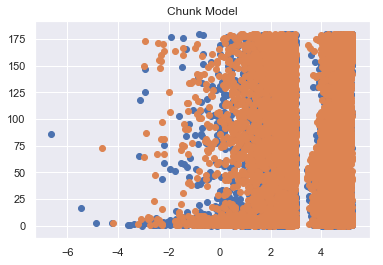

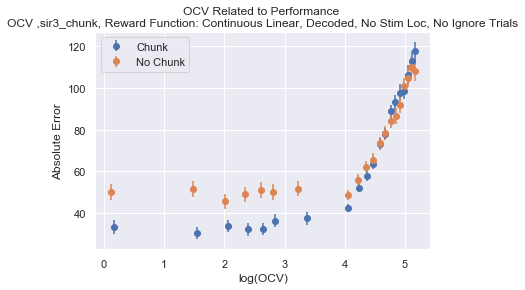

In [5]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base.csv',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


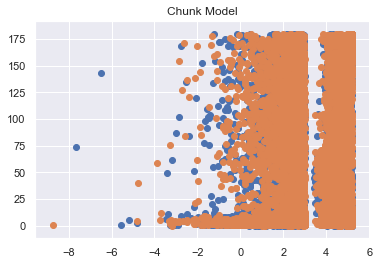

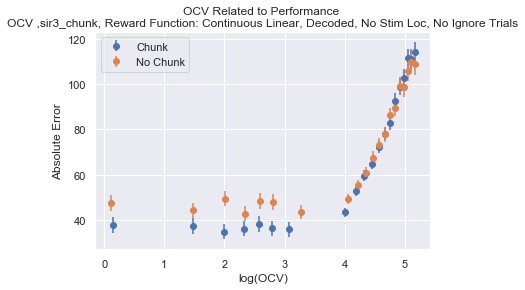

In [4]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base.csv',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


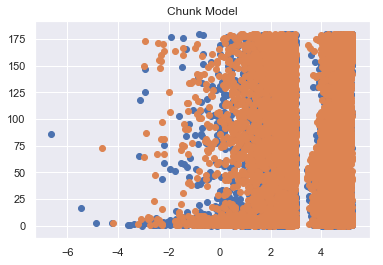

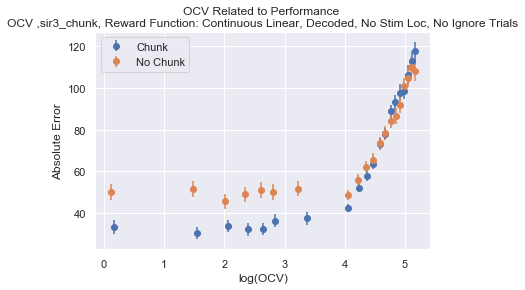

In [6]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base.csv',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


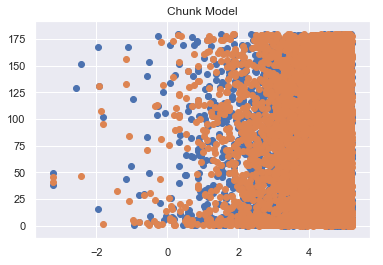

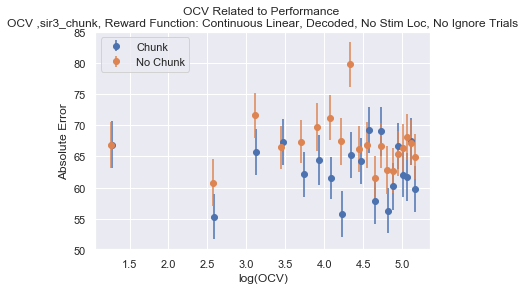

In [4]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base.csv',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


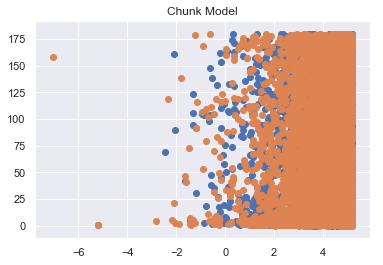

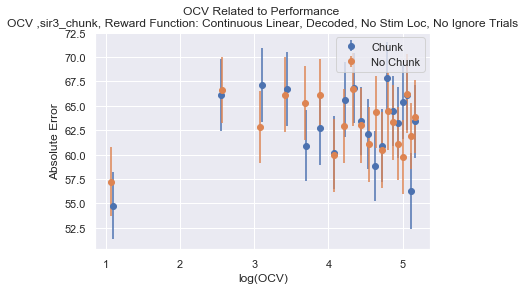

In [33]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base100',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


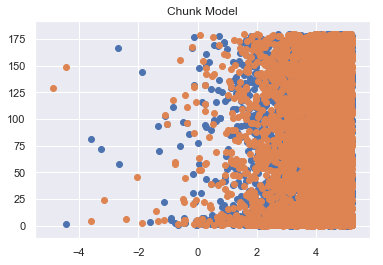

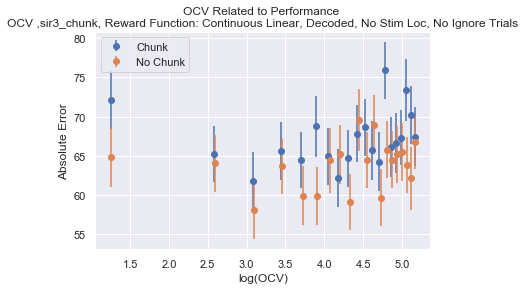

In [34]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base200',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


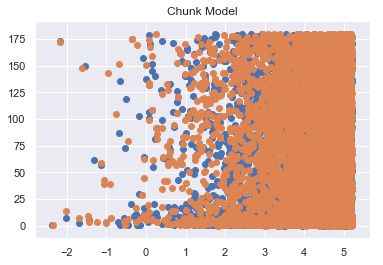

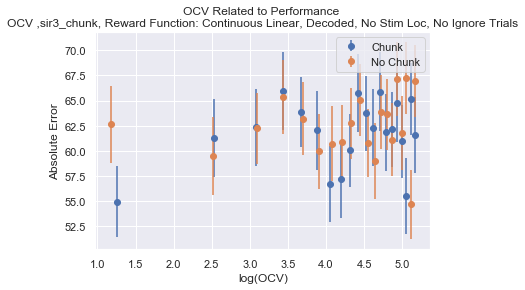

In [35]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base300',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


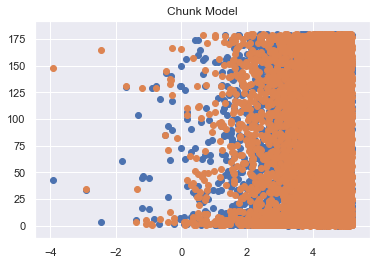

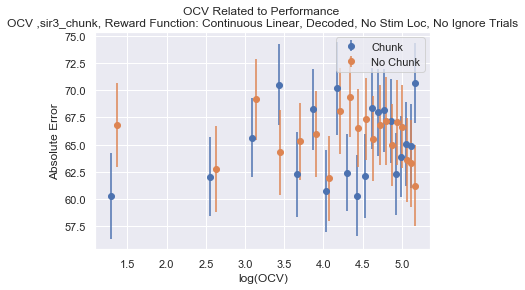

In [36]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base400',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


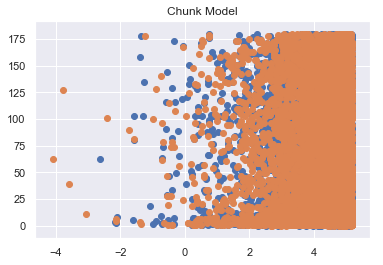

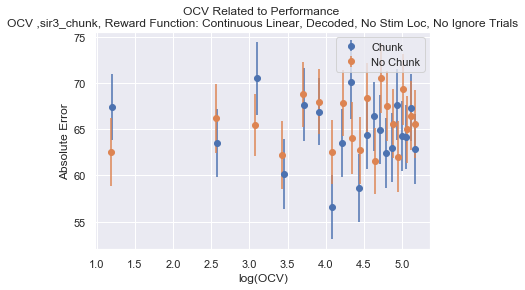

In [37]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base500',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


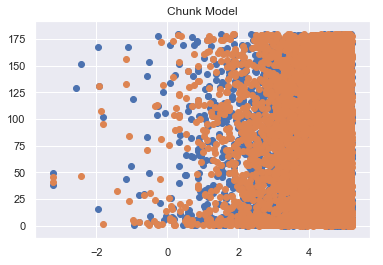

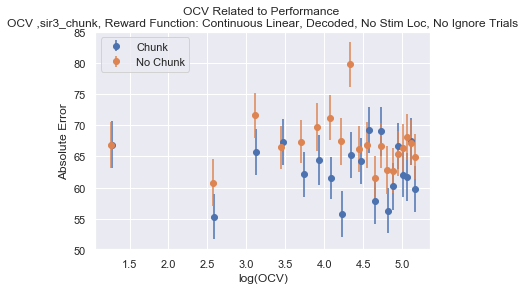

In [38]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base.csv',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
df = pd.read_csv(base2+"sir3model0_RewThreshold5.5_decoded_Base100.csv", sep = "\t")

In [29]:
df

,|Run,|Epoch,|Trial,$TrialName,#Err,#TrlDecodedDiff,#SSE,#AvgSSE,#CosDiff,#DA,...,"#PFCoutD[4:1,0,0,18]","#PFCoutD[4:1,0,0,19]",#stripe,#stripe,#OutDecode,#OutTarget,#InDecode,$Lesion,#LesionProp,$LesionApplied
0,0,-1,0,Store2_138.44207413609342_mnt1_-1_mnt2_138.442...,0,9.1740,0.0000,0.00000,0.95800,0.00000,...,8.445000e-09,8.514000e-09,285.500,358.50,146.700,137.600,137.600,Hidden,0,no
1,0,-1,1,Recall2_138.44207413609342_mnt1_-1_mnt2_-1_mnt...,1,188.6000,4.0120,0.20060,-0.45790,-0.63200,...,5.833000e-01,5.880000e-01,285.500,358.50,326.200,137.600,0.000,Hidden,0,no
2,0,-1,2,Store2_316.0549650622429_mnt1_-1_mnt2_316.0549...,1,29.6400,0.8168,0.04084,0.76200,0.00000,...,8.445000e-09,8.514000e-09,285.500,358.50,291.400,321.000,321.000,Hidden,0,no
3,0,-1,3,Store1_184.25462662789778_mnt1_184.25462662789...,0,0.6835,0.0000,0.00000,0.96540,0.00000,...,5.833000e-01,5.880000e-01,187.300,358.50,185.700,185.000,185.000,Hidden,0,no
4,0,-1,4,Recall2_316.0549650622429_mnt1_184.25462662789...,1,19.8100,2.2930,0.11470,0.13260,0.21700,...,5.833000e-01,5.880000e-01,187.300,358.50,340.900,321.000,0.000,Hidden,0,no
5,0,-1,5,Store2_108.31940708037116_mnt1_184.25462662789...,1,39.6700,1.2010,0.06007,0.55930,0.00000,...,8.445000e-09,8.514000e-09,187.300,358.50,148.800,109.100,109.100,Hidden,0,no
6,0,-1,6,Recall2_108.31940708037116_mnt1_184.2546266278...,1,237.0000,2.9340,0.14670,-0.38040,-0.35640,...,5.833000e-01,5.880000e-01,187.300,358.50,346.100,109.100,0.000,Hidden,0,no
7,0,-1,7,Recall1_184.25462662789778_mnt1_-1_mnt2_-1_mnt...,1,154.8000,1.7830,0.08913,0.18610,-0.62130,...,5.833000e-01,5.880000e-01,187.300,358.50,339.900,185.000,0.000,Hidden,0,no
8,0,-1,8,Store3_225.18281194443577_mnt1_-1_mnt2_-1_mnt3...,1,34.7500,1.6850,0.08424,0.64220,0.00000,...,5.833000e-01,5.880000e-01,187.300,226.60,190.800,225.500,225.500,Hidden,0,no
9,0,-1,9,Recall3_225.18281194443577_mnt1_-1_mnt2_-1_mnt...,1,15.3700,0.8489,0.04244,0.77920,0.23260,...,8.445000e-09,8.513000e-09,187.300,226.60,210.100,225.500,0.000,Hidden,0,no


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:409: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


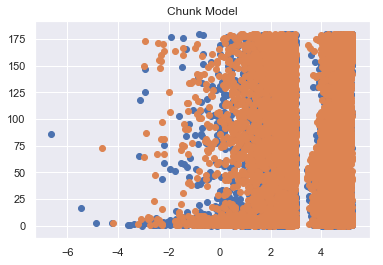

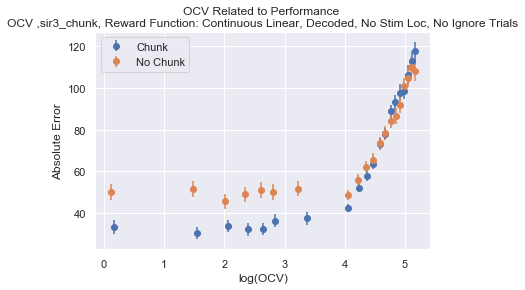

In [25]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/chunktrials/"
chunkOCV, chunkOdf, chunkdf_recall, nochunkOCV, nochunkOdf, nochunkdf_recall = plot_ocv_two(base1,base2,extra_exp = 'Base.csv',var = 'diff', uniform = True,bins_equal_size = True, nbins = 20)

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\pyplot.py:514: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


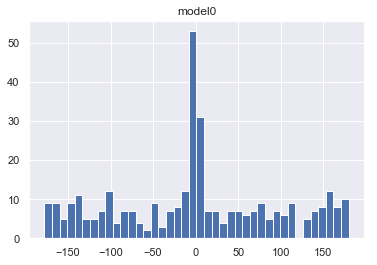

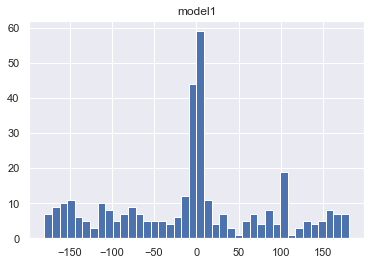

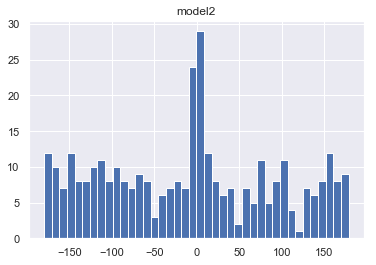

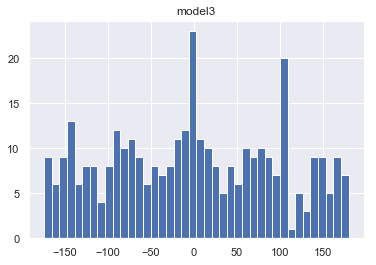

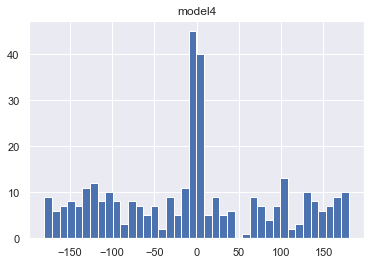

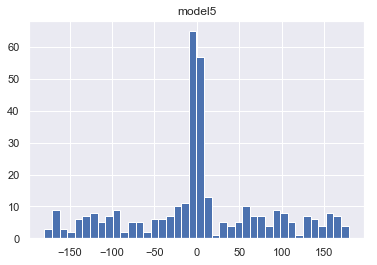

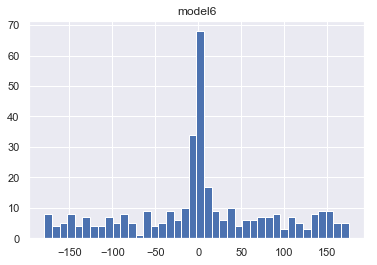

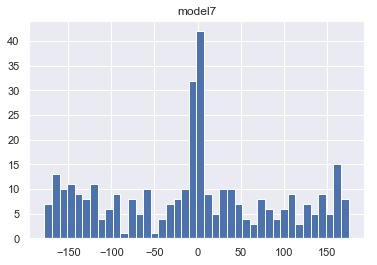

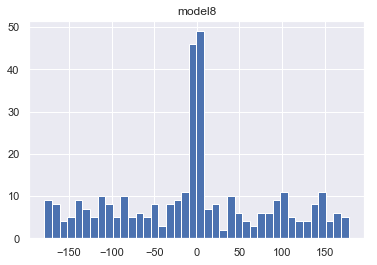

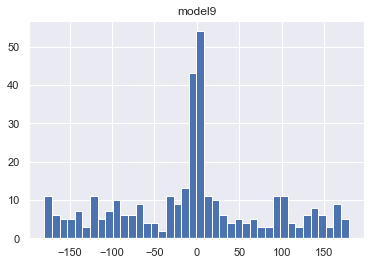

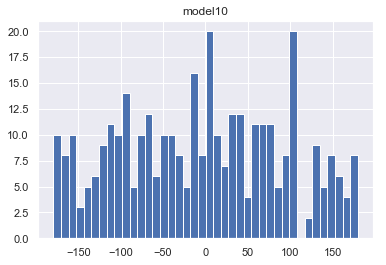

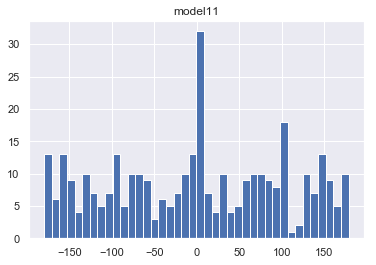

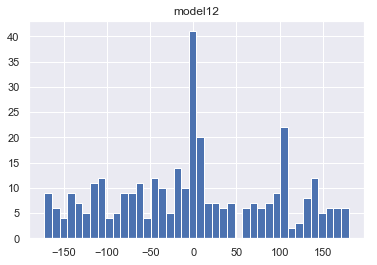

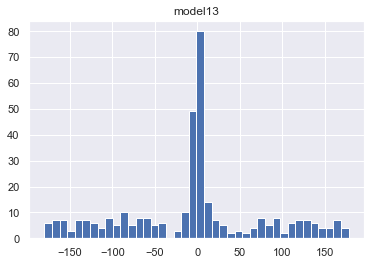

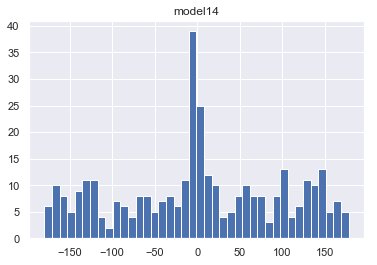

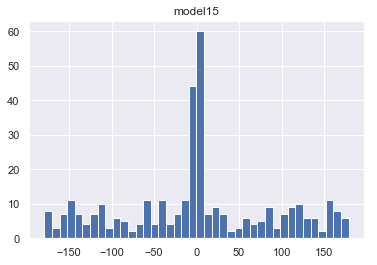

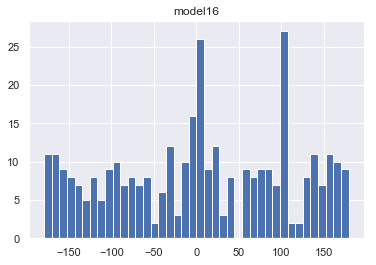

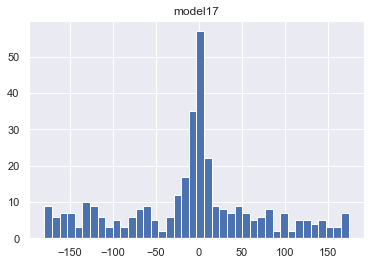

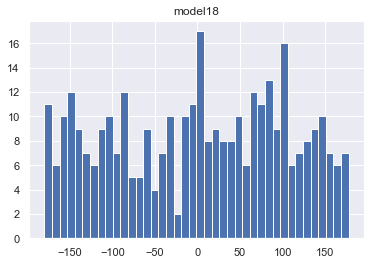

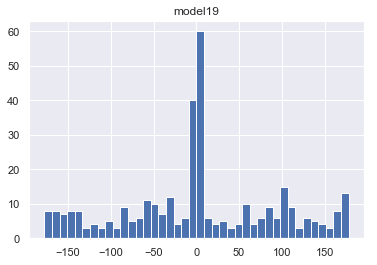

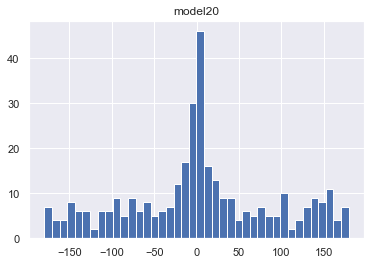

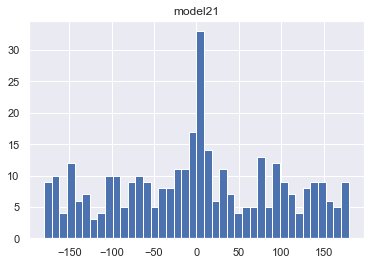

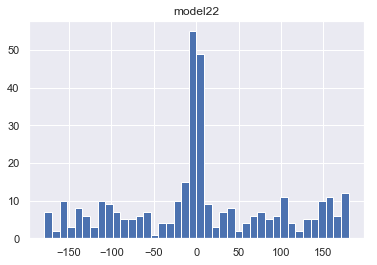

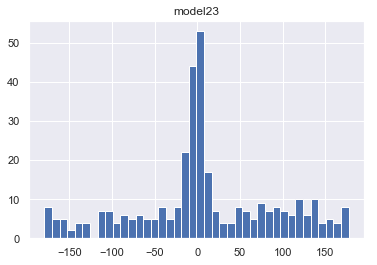

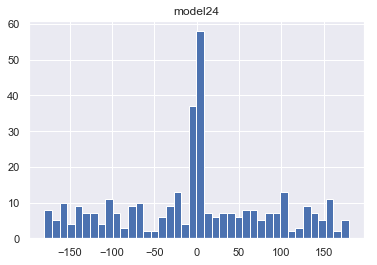

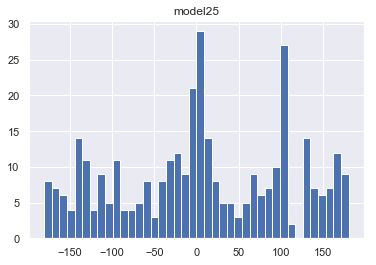

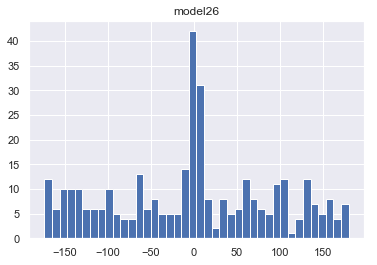

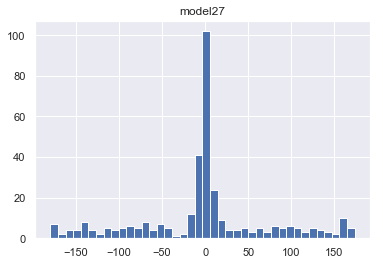

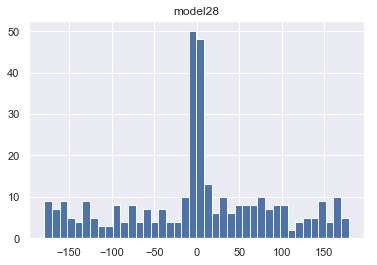

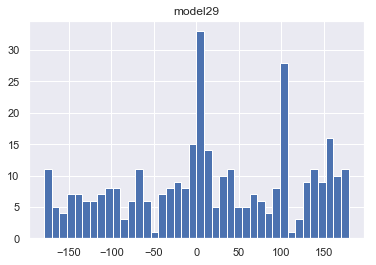

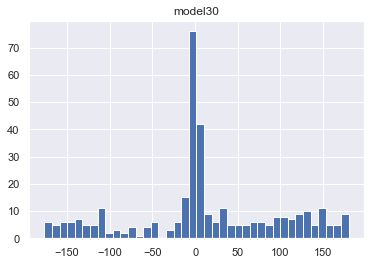

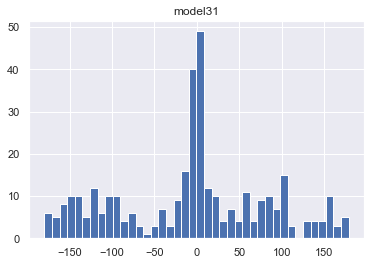

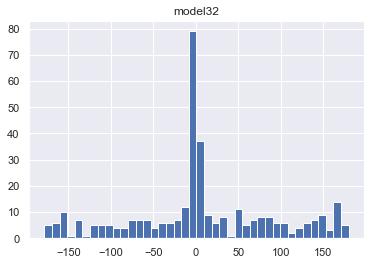

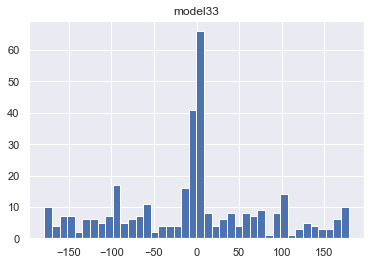

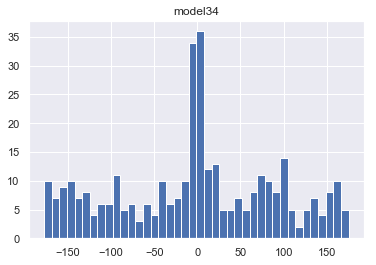

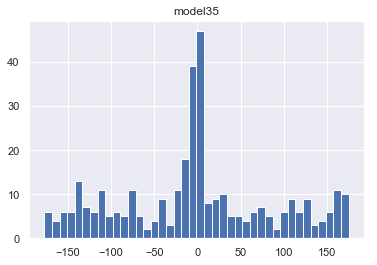

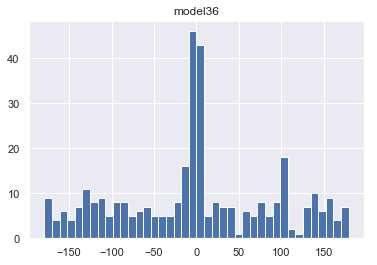

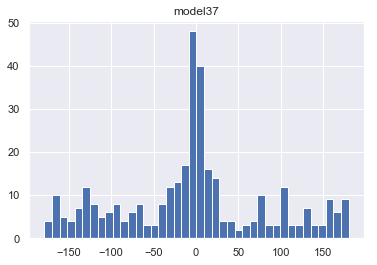

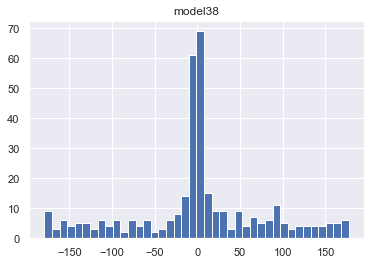

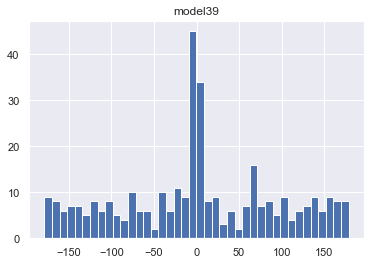

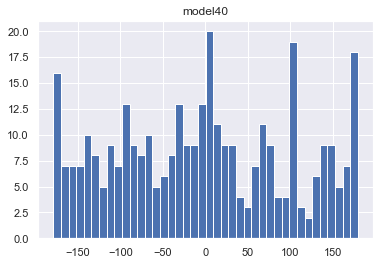

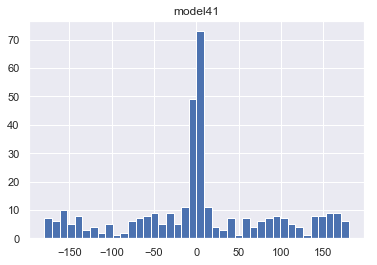

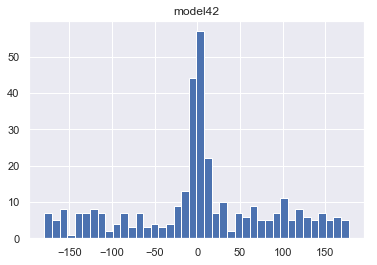

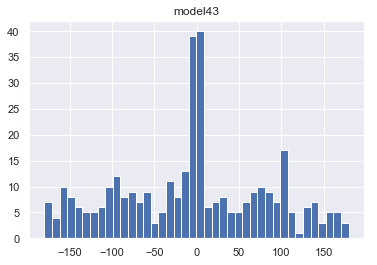

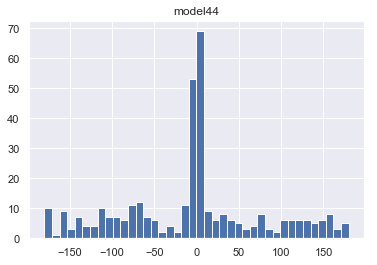

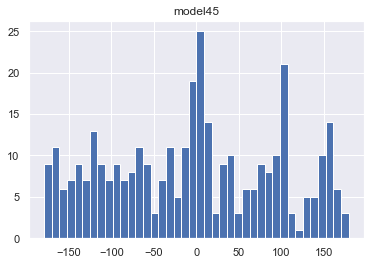

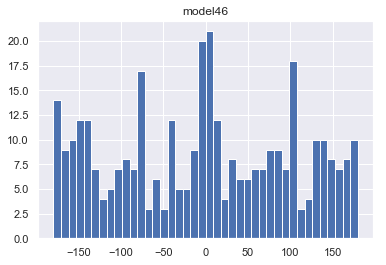

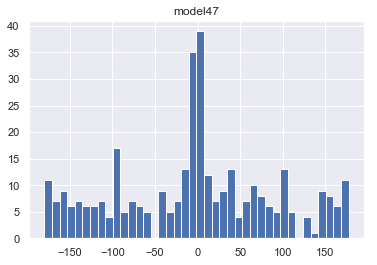

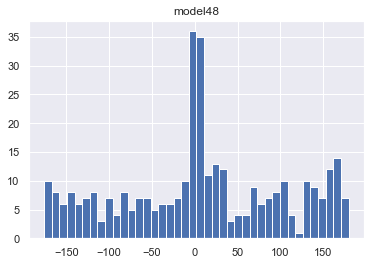

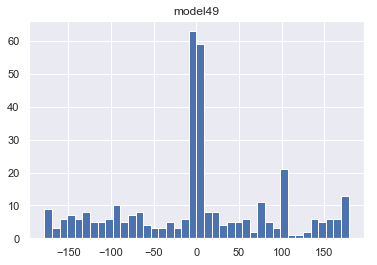

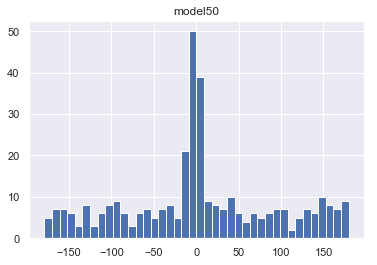

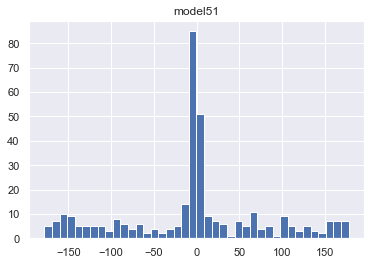

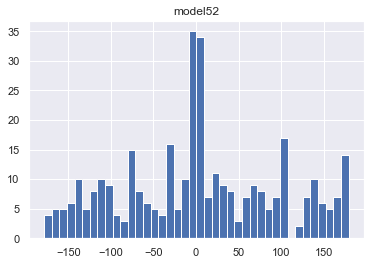

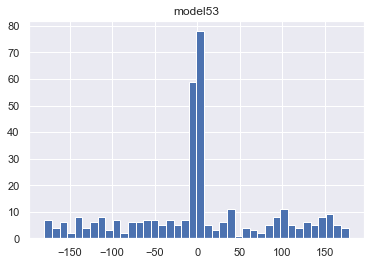

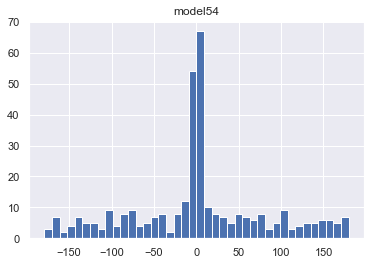

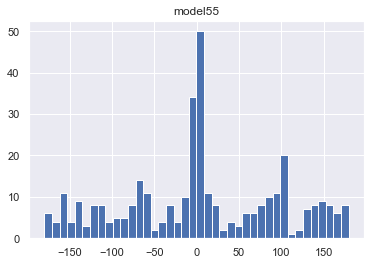

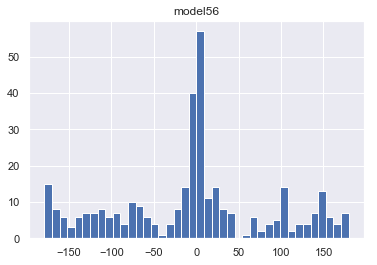

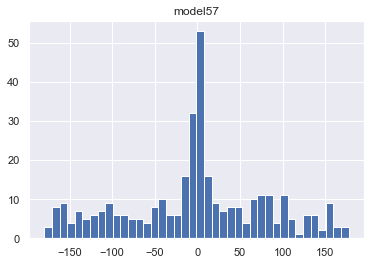

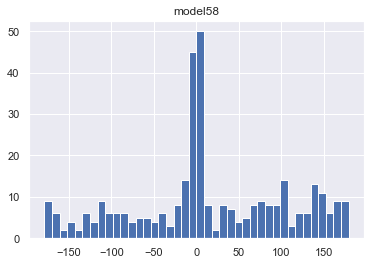

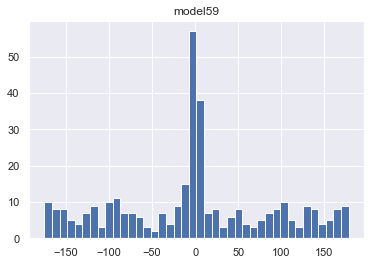

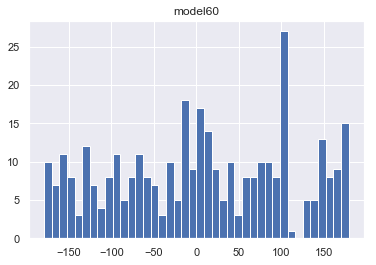

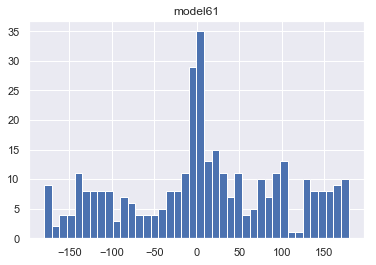

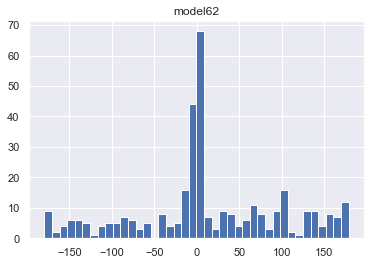

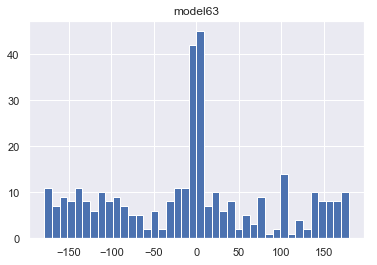

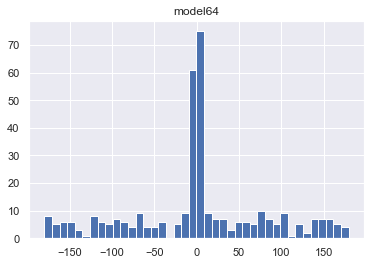

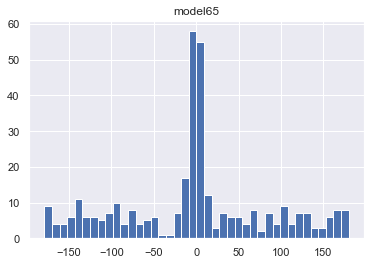

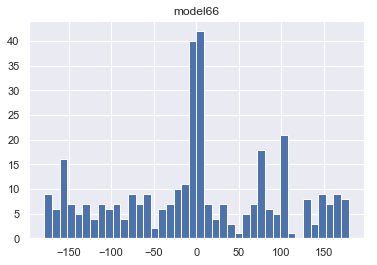

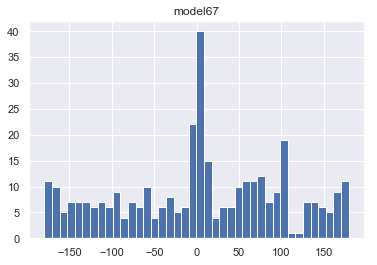

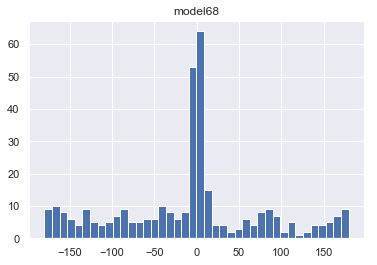

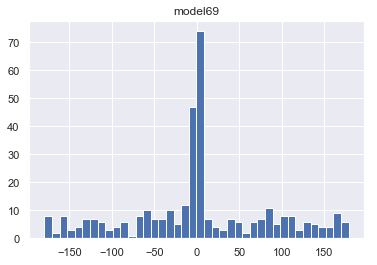

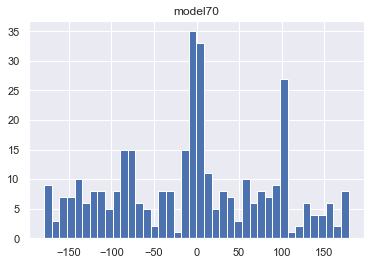

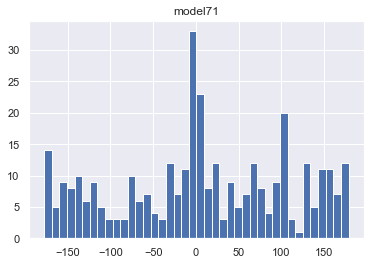

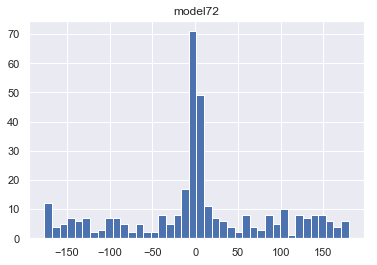

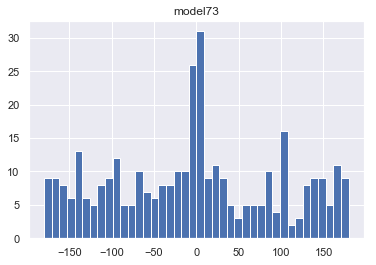

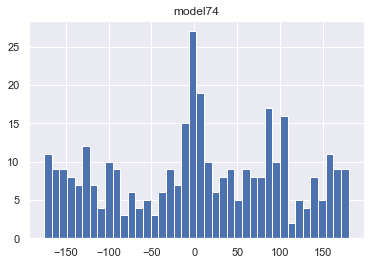

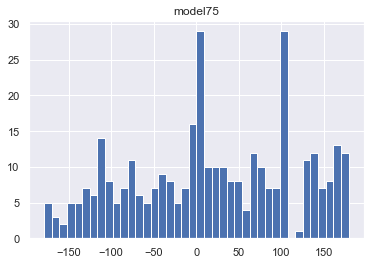

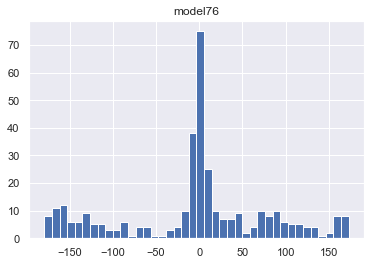

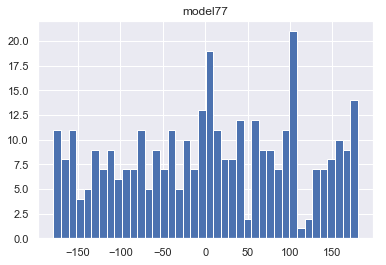

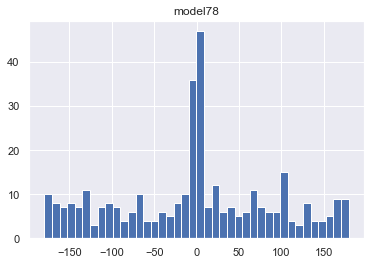

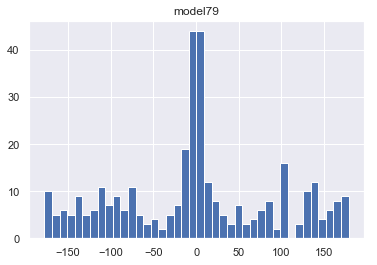

In [18]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
full_files = getfiles(base1)
i = 0 
for f in full_files:
    p = Precision()
    err = p.mult_models([f])
    plt.figure()
    plt.hist(err, bins = 40)
    plt.title("model"+str(i))
    i +=1

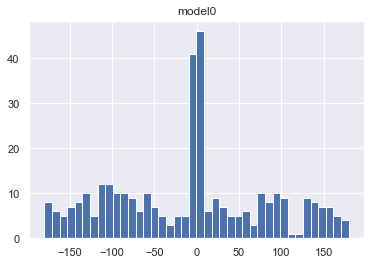

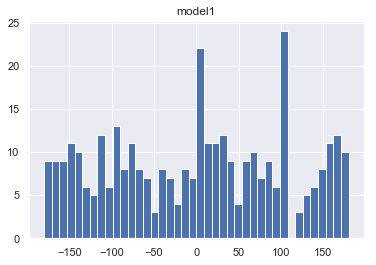

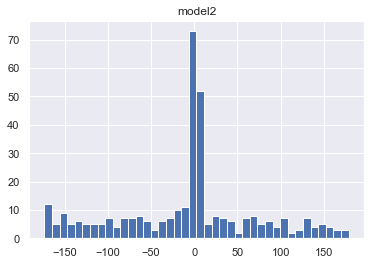

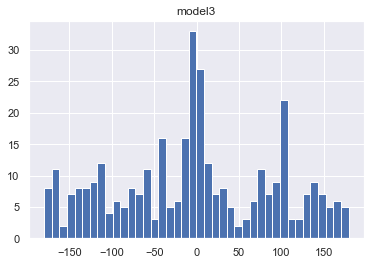

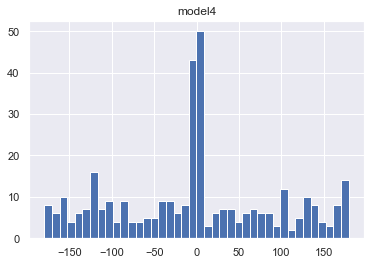

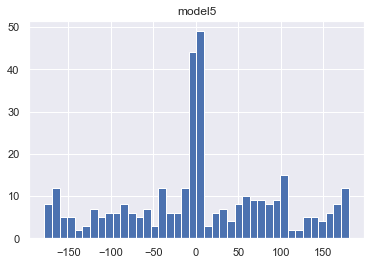

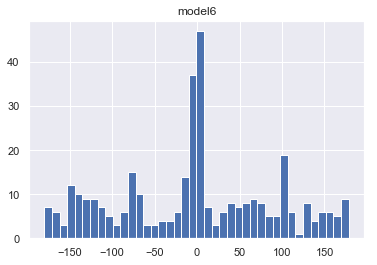

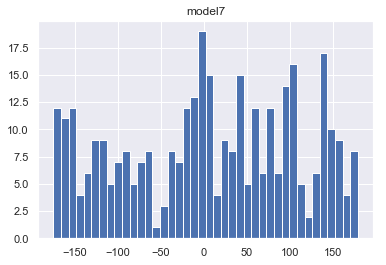

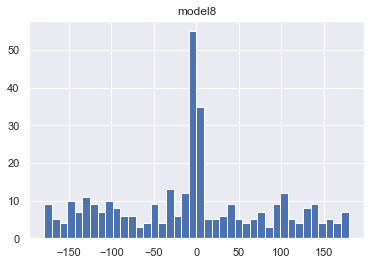

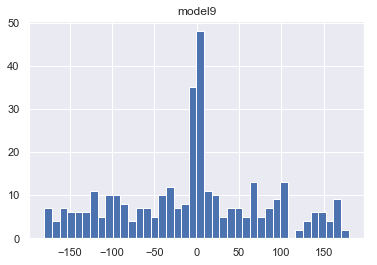

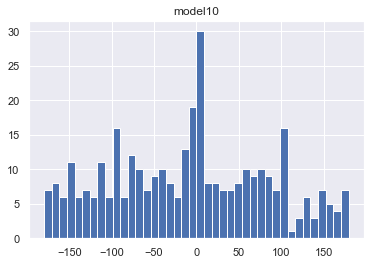

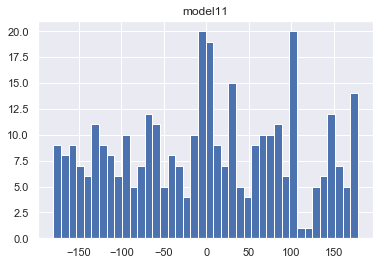

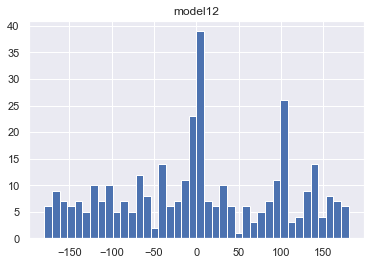

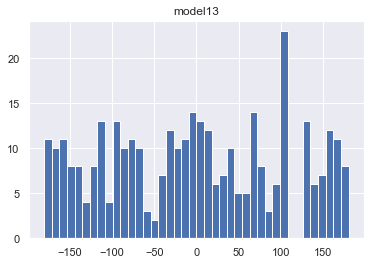

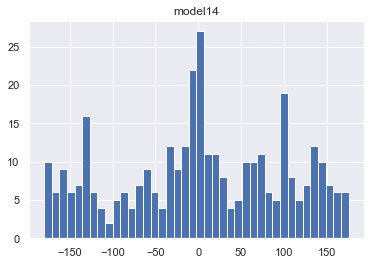

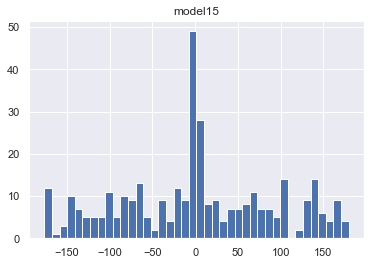

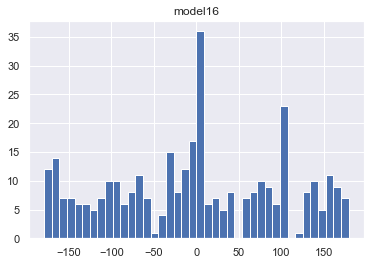

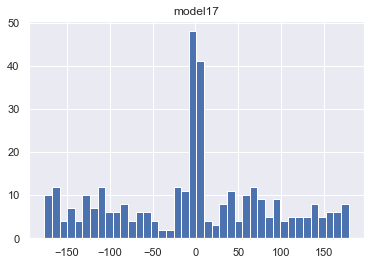

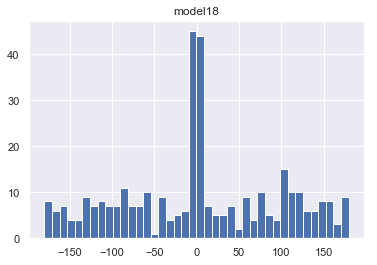

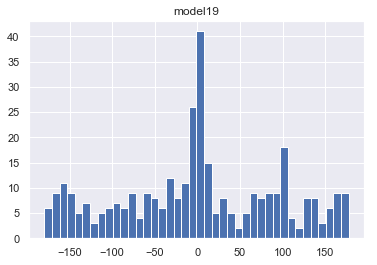

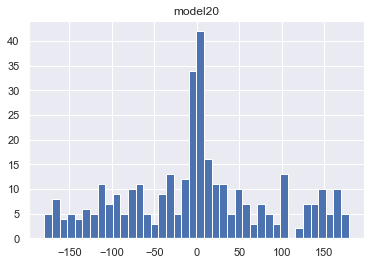

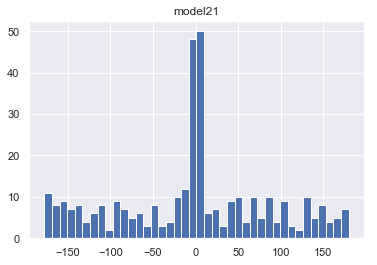

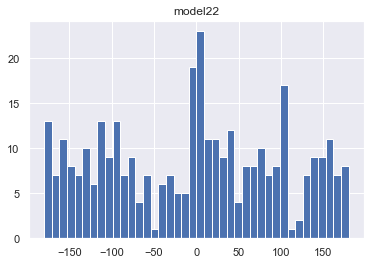

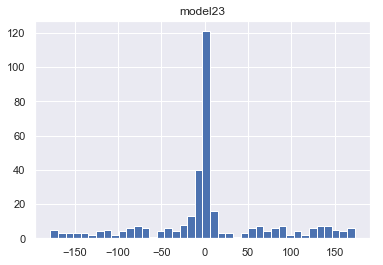

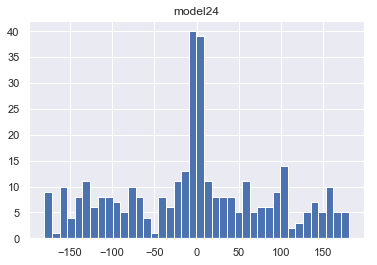

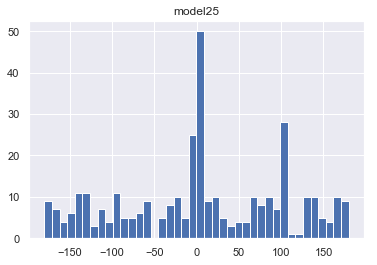

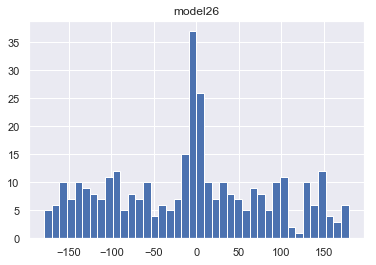

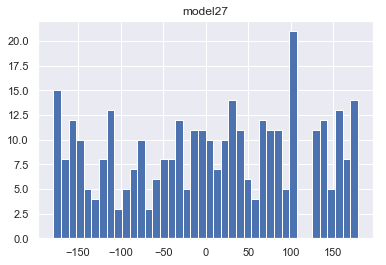

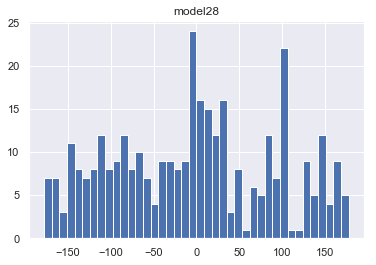

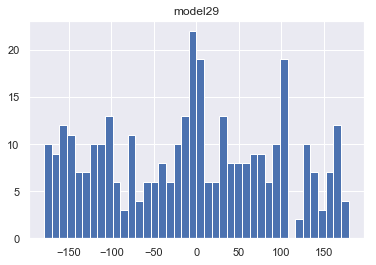

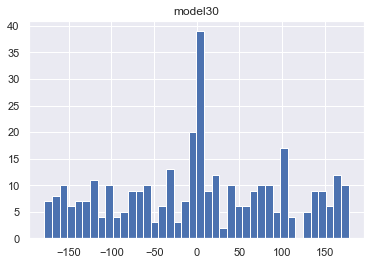

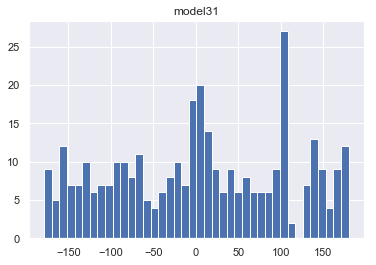

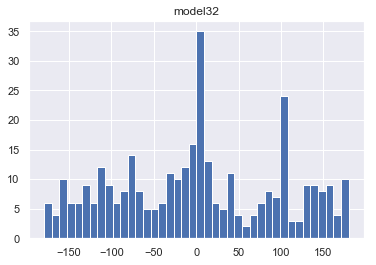

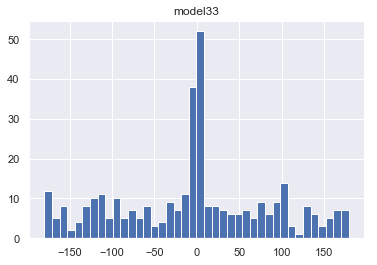

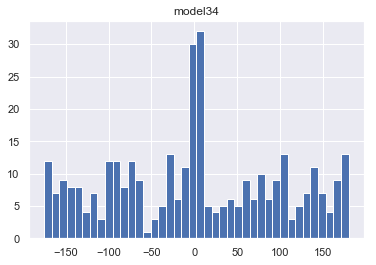

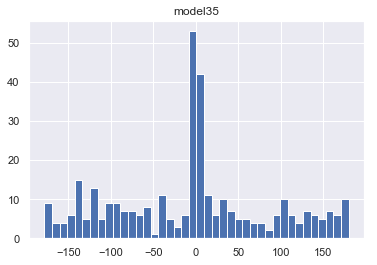

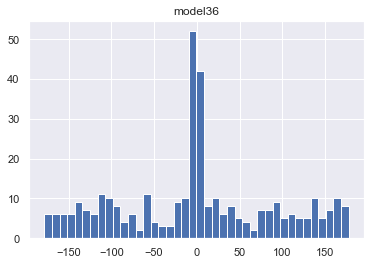

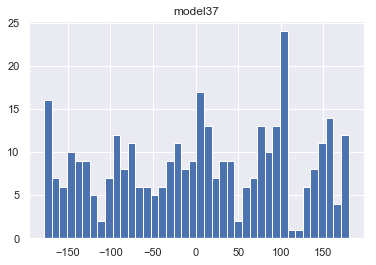

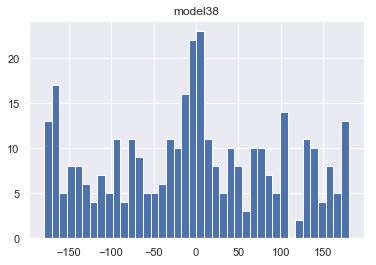

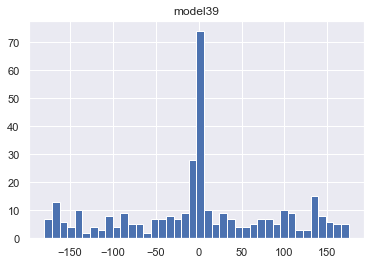

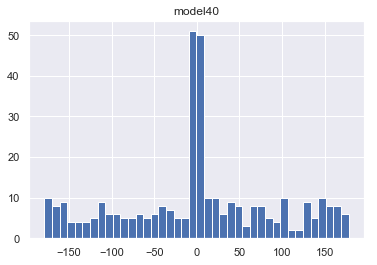

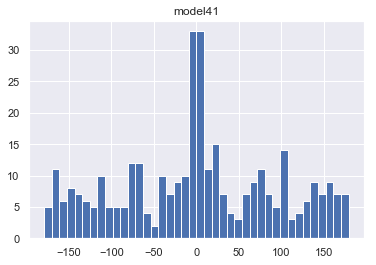

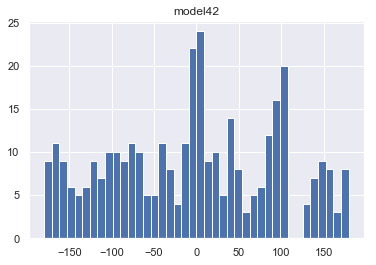

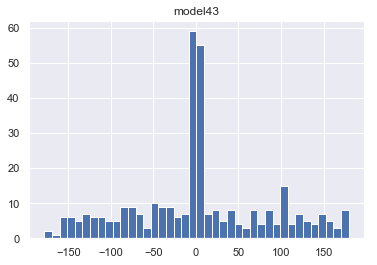

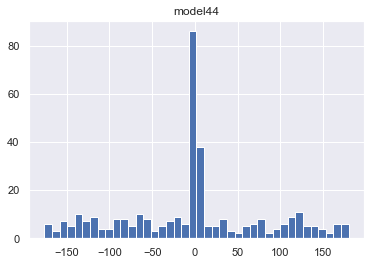

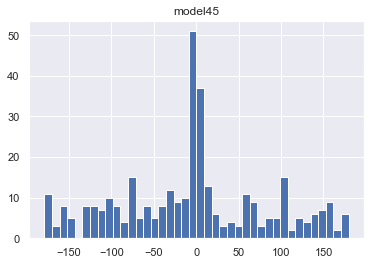

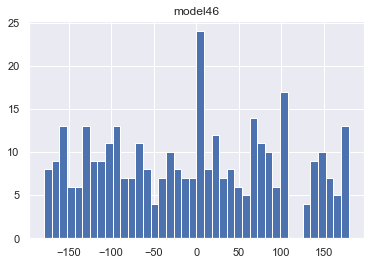

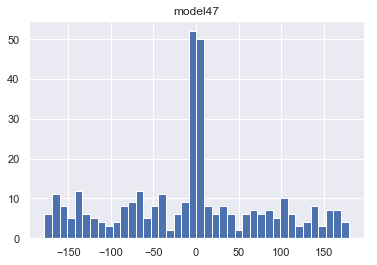

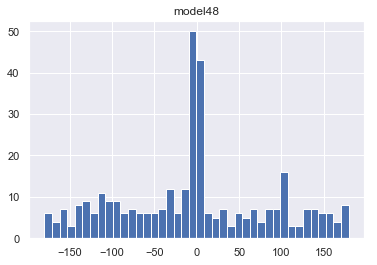

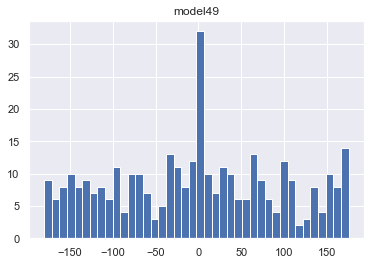

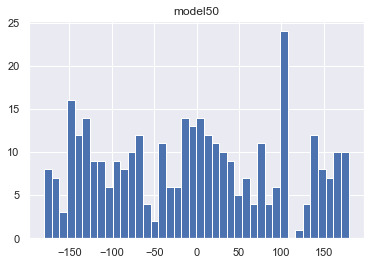

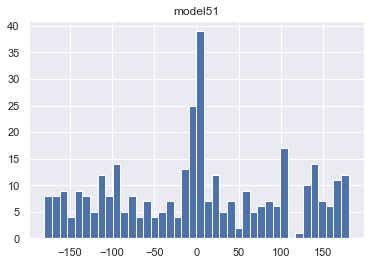

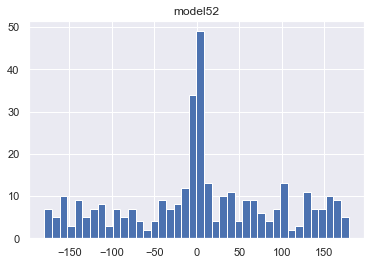

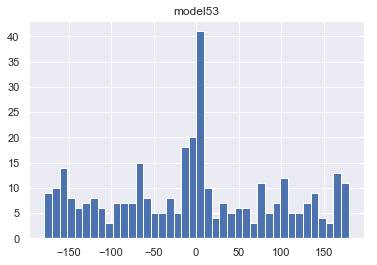

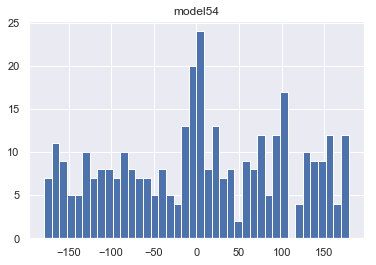

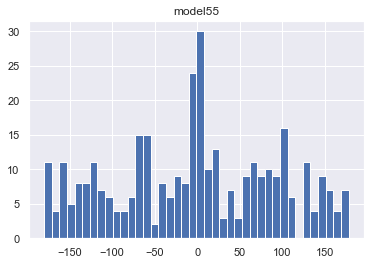

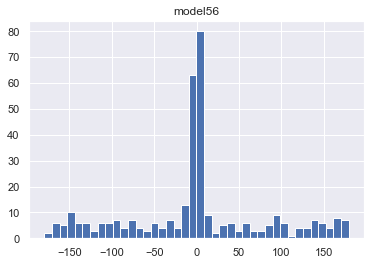

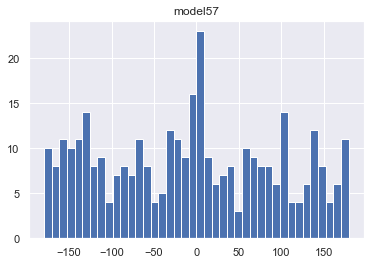

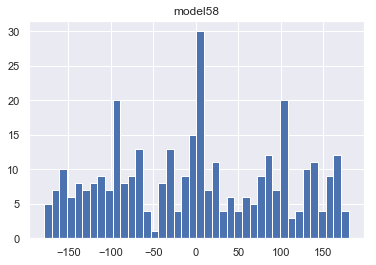

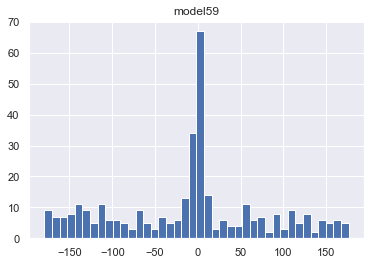

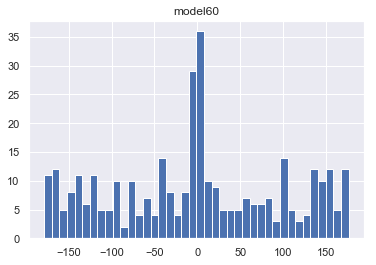

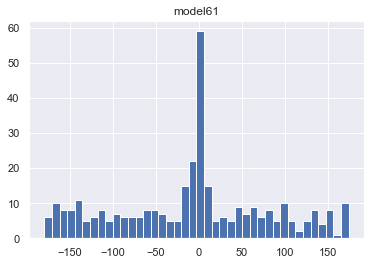

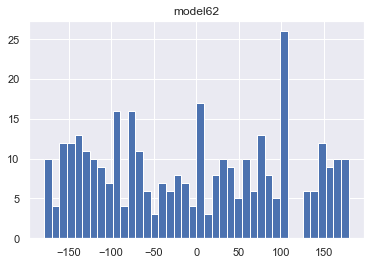

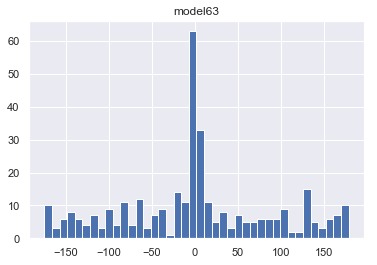

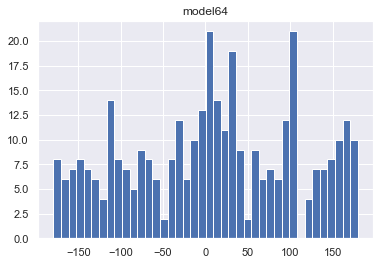

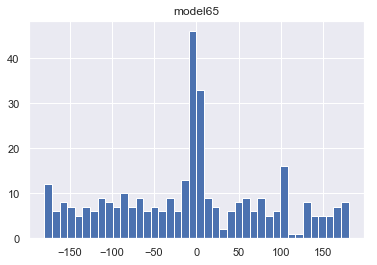

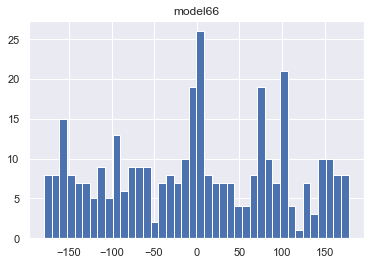

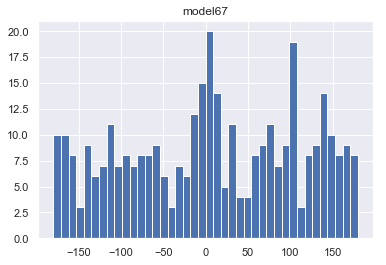

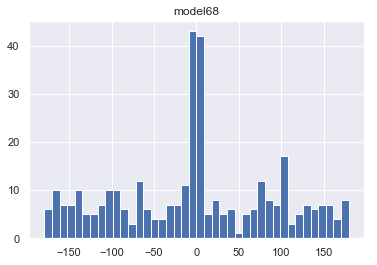

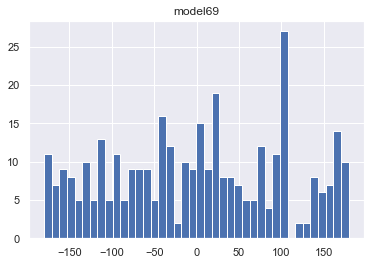

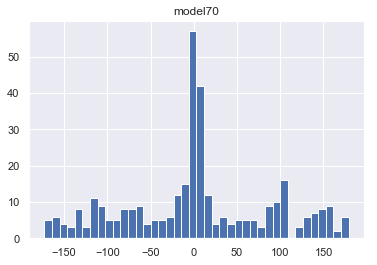

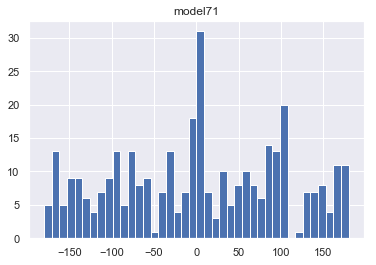

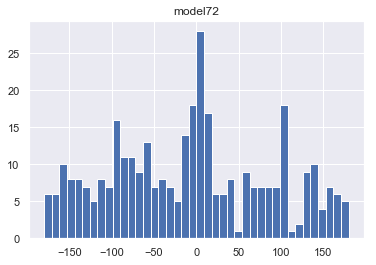

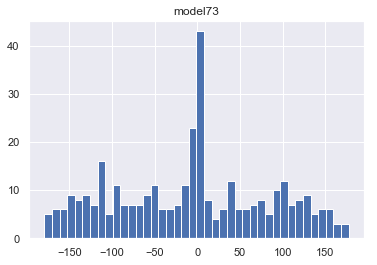

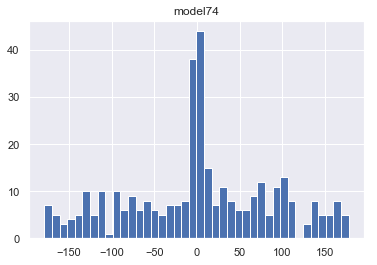

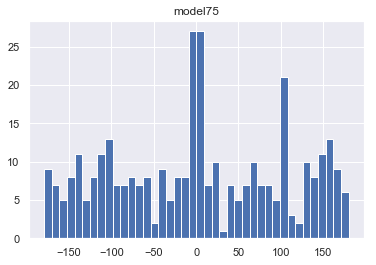

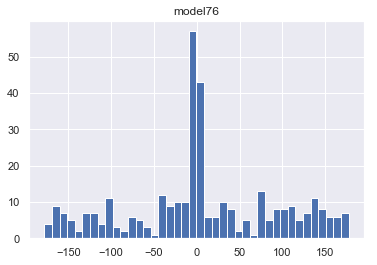

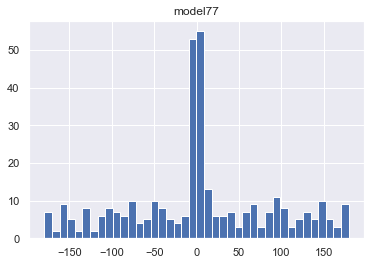

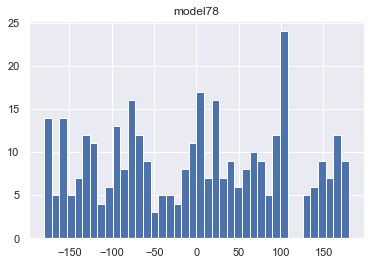

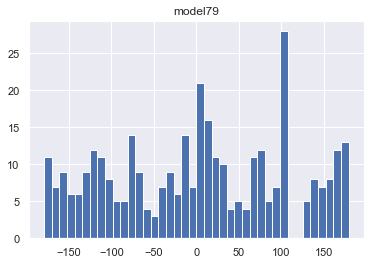

In [25]:
base1= "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
full_files = getfiles(base1)
i = 0 
for f in full_files:
    p = Precision()
    err = p.mult_models([f])
    plt.figure()
    plt.hist(err, bins = 40)
    plt.title("model"+str(i))
    i +=1

80
80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80
80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


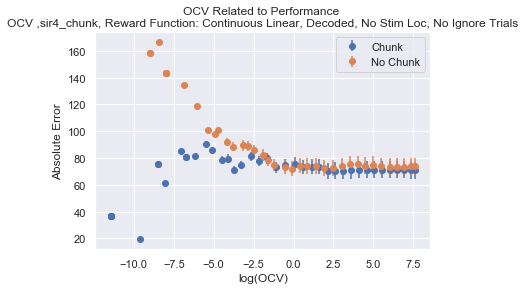

In [51]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2,extra_exp = 'Base100')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


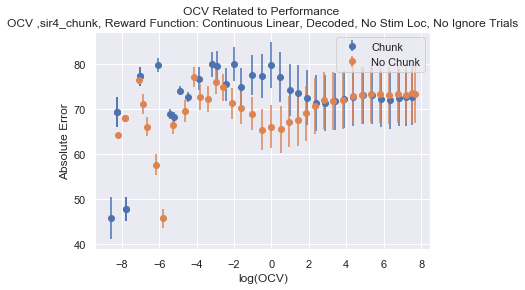

In [58]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2,extra_exp = 'Base200')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


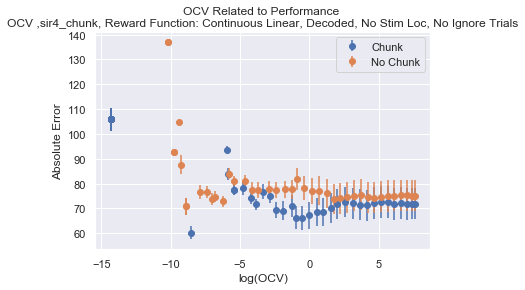

In [59]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2,extra_exp = 'Base300')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


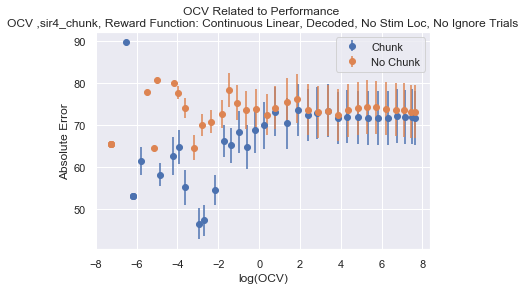

In [60]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2, extra_exp = 'Base400')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


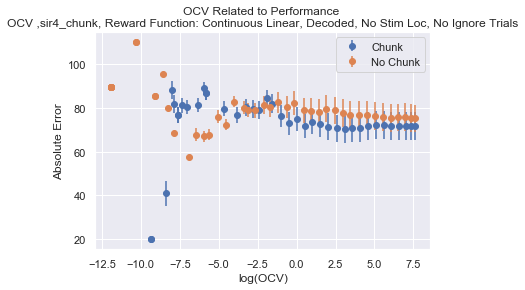

In [61]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2,extra_exp = 'Base500')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


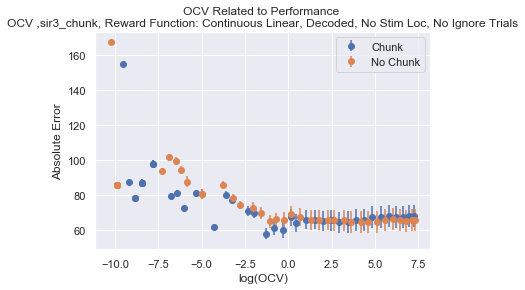

In [53]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2, extra_exp = 'Base100')


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


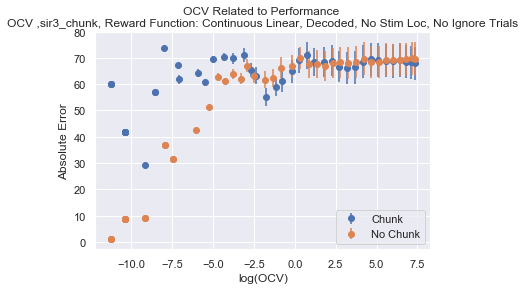

In [54]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2, extra_exp = 'Base200')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


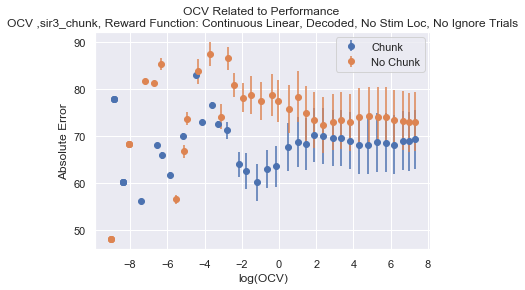

In [55]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2, extra_exp = 'Base300')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


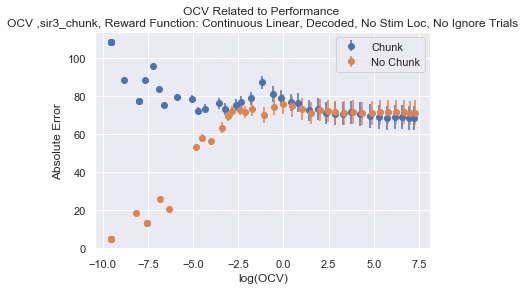

In [56]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2, extra_exp = 'Base400')

80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:370: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:395: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


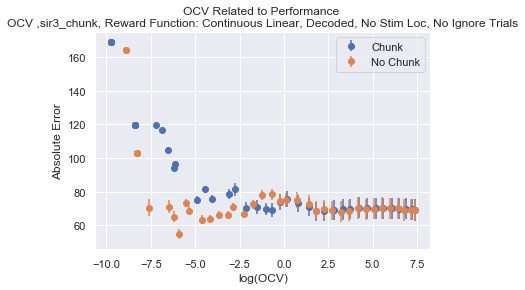

In [57]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
plot_ocv_two(base1,base2, extra_exp = 'Base500')

In [66]:
base.split('/')[1]

'sir3_chunk'

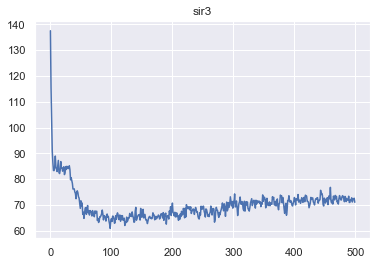

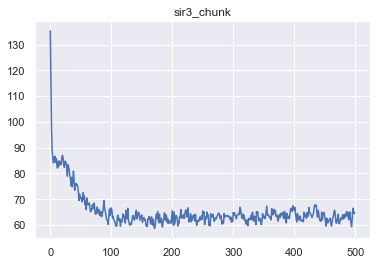

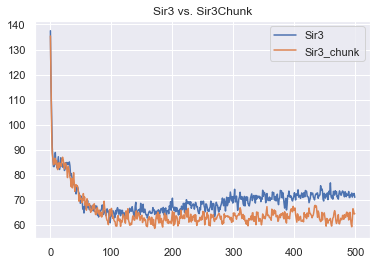

In [2]:
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
sir3,Epoch = training_curve_average(base)
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
sir3_chunk,Epoch = training_curve_average(base)

plt.plot(Epoch[0],sir3)
plt.plot(Epoch[0], sir3_chunk)
plt.legend(['Sir3', 'Sir3_chunk'])
plt.title('Sir3 vs. Sir3Chunk')
plt.show()

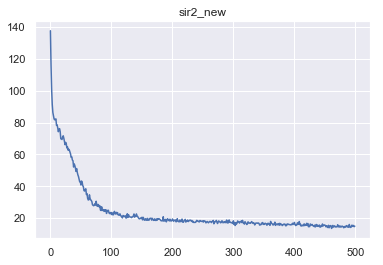

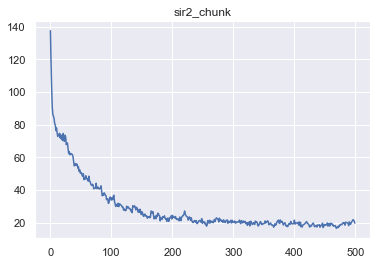

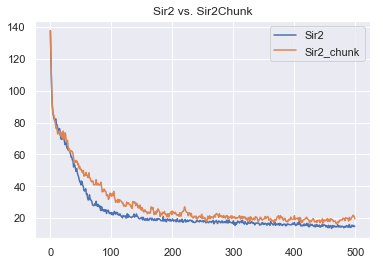

In [4]:
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
sir2,Epoch = training_curve_average(base)
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
sir2_chunk,Epoch = training_curve_average(base)

plt.plot(Epoch[0],sir2)
plt.plot(Epoch[0], sir2_chunk)
plt.legend(['Sir2', 'Sir2_chunk'])
plt.title('Sir2 vs. Sir2Chunk')
plt.show()

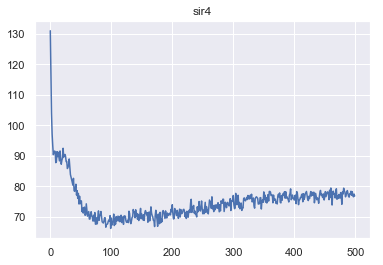

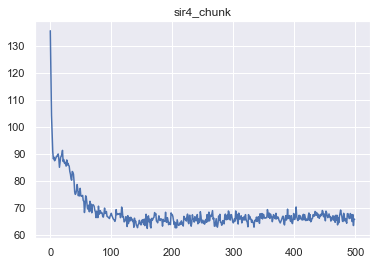

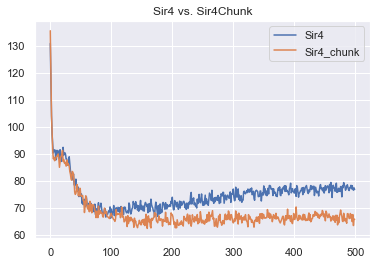

In [5]:
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
sir4,Epoch = training_curve_average(base)
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
sir4_chunk,Epoch = training_curve_average(base)

plt.plot(Epoch[0],sir4)
plt.plot(Epoch[0], sir4_chunk)
plt.legend(['Sir4', 'Sir4_chunk'])
plt.title('Sir4 vs. Sir4Chunk')
plt.show()

80
68


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:369: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


80
54


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:393: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


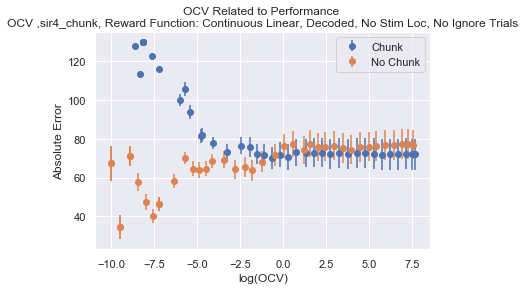

In [48]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chunk_bad = ['3','10','16','18','40','45','46','60','71','74','75','77']
chunk_bad = [base1+"sir4chunkhybridmodel"+i+"_RewThreshold5.5_decoded_Base.csv" for i in chunk_bad]
nochunk_bad = ['1','7','11','13','14','22','27','28','29','31','37','38','42','46','50','54','57','62','64','66','67','69','72','75','78','79']
nochunk_bad = [base2+"sir4model"+i+"_RewThreshold5.5_decoded_Base.csv" for i in nochunk_bad]
plot_ocv_two(base1,base2,chunk_bad=chunk_bad, nochunk_bad = nochunk_bad)

In [ ]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
chunk_bad = ['3','10','16','18','40','45','46','60','71','74','75','77']
chunk_bad = [base1+"sir4chunkhybridmodel"+i+"_RewThreshold5.5_decoded_Base.csv" for i in chunk_bad]
nochunk_bad = ['1','7','11','13','14','22','27','28','29','31','37','38','42','46','50','54','57','62','64','66','67','69','72','75','78','79']
nochunk_bad = [base2+"sir4model"+i+"_RewThreshold5.5_decoded_Base.csv" for i in nochunk_bad]
plot_ocv_two(base1,base2,chunk_bad=chunk_bad, nochunk_bad = nochunk_bad, var = "diff")
print('no log ocv')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:367: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:387: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


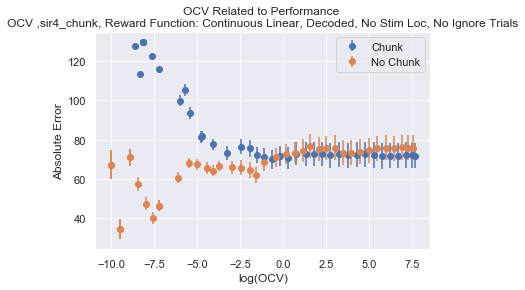

In [32]:
base1= "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base2 = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
plot_ocv_two(base1,base2)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:232: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


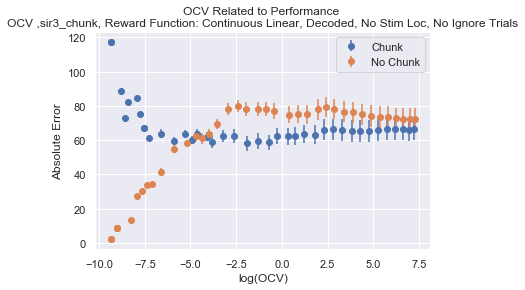

In [5]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
plot_ocv_two(base1,base2)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:220: RuntimeWarning: invalid value encountered in log
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:232: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:237: RuntimeWarning: invalid value encountered in log


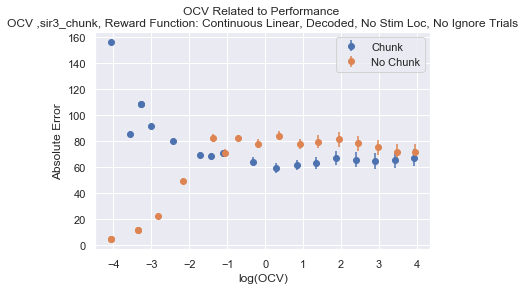

In [13]:
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
plot_ocv_two(base1,base2, var = "diff")

(array([ 421.,  378.,  430.,  453.,  395.,  379.,  423.,  376.,  399.,
         382.,  428.,  415.,  399.,  408.,  481.,  265.,  426.,  408.,
         388.,  650.,  723., 4864., 5233.,  571.,  465.,  449.,  458.,
         440.,  263.,  518.,  374.,  464.,  389.,  439.,  658.,  364.,
         208.,  341.,  418.,  432.,  442.,  390.,  412.,  323.]),
 array([-180.        , -171.81818182, -163.63636364, -155.45454545,
        -147.27272727, -139.09090909, -130.90909091, -122.72727273,
        -114.54545455, -106.36363636,  -98.18181818,  -90.        ,
         -81.81818182,  -73.63636364,  -65.45454545,  -57.27272727,
         -49.09090909,  -40.90909091,  -32.72727273,  -24.54545455,
         -16.36363636,   -8.18181818,    0.        ,    8.18181818,
          16.36363636,   24.54545455,   32.72727273,   40.90909091,
          49.09090909,   57.27272727,   65.45454545,   73.63636364,
          81.81818182,   90.        ,   98.18181818,  106.36363636,
         114.54545455,  122.72727273, 

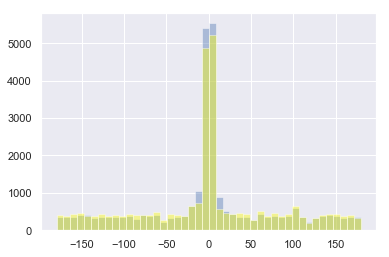

In [11]:
p = Precision()
errchunk = p.mult_models(getfiles(base1))
plt.hist(errchunk,bins = np.linspace(-180,180,45), alpha = 0.4)
p = Precision()
err = p.mult_models(getfiles(base2))
plt.hist(err,bins = np.linspace(-180,180,45), alpha = 0.4, color = "yellow")


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:232: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


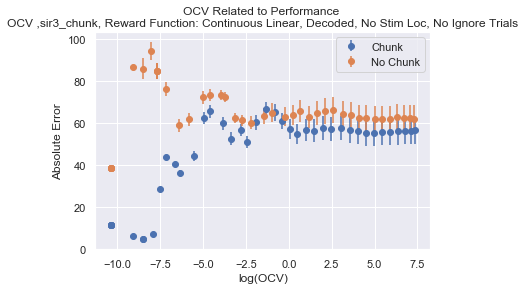

In [7]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:220: RuntimeWarning: invalid value encountered in log
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:232: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:237: RuntimeWarning: invalid value encountered in log


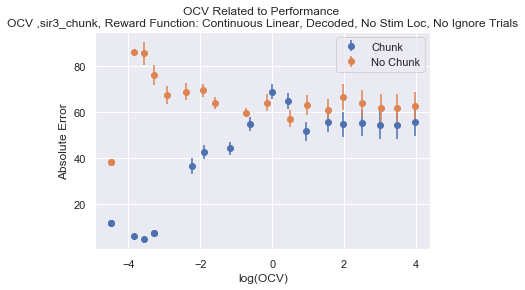

In [12]:
base2 = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/"
base1= "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/"
plot_ocv_two(base1,base2,var = "diff")